In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots



In [3]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [4]:
function standardEstimator(points, weights, depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets',weights)

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end


function standardEstimator(points,depth = 9)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets')

    simplices = coords[:,tets]
    bvh = BVH(simplices,depth)

    return bvh,tes,tets
end

function DTFE(point,bvh,tetrahedra,tesselation)

    coords = tesselation.points
    simplices = coords[tetrahedra]

    i = TesselationCore.findID(point,simplices,bvh)
    if i == nothing
        return 0
    end

    tet = tetrahedra[i,:]
    simp = coords[tet]
    rhos = tesselation.ρStar[tet]

    delRho=invertClassic(rhos,simp)

    interpolation = rhos[1] + dot((point - simp[1]),delRho)

    return interpolation
end

function invertClassic(rhos,simplex) 
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end



invertClassic (generic function with 1 method)

In [ ]:
import illustris_julia as il


basePath = "../../DTFE/Illustris3/output";

fields = ["Masses","Coordinates","ParticleIDs"];

load135 = il.snapshot.loadSubset(basePath,135,"gas",fields)
gap = 10000
points = load135["Coordinates"][:,1:gap:end]

load135 = nothing
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = standardEstimator(ps,12)

(Main.TesselationCore.Bvh.BVH(Main.TesselationCore.Bvh.BVHNode(12, Main.TesselationCore.Bvh.BVHNode(11, Main.TesselationCore.Bvh.BVHNode(10, Main.TesselationCore.Bvh.BVHNode(9, Main.TesselationCore.Bvh.BVHNode(8, Main.TesselationCore.Bvh.BVHNode(7, Main.TesselationCore.Bvh.BVHNode(6, Main.TesselationCore.Bvh.BVHNode(5, Main.TesselationCore.Bvh.BVHNode(4, Main.TesselationCore.Bvh.BVHNode(3, Main.TesselationCore.Bvh.BVHNode(2, Main.TesselationCore.Bvh.BVHNode(1, Main.TesselationCore.Bvh.BVHLeaf([49, 217, 292, 1369, 1488, 1490]), Main.TesselationCore.Bvh.BVHLeaf([49, 154, 217, 292, 654, 1369, 1381, 1488, 1490, 2552, 2585, 2886])), Main.TesselationCore.Bvh.BVHNode(1, Main.TesselationCore.Bvh.BVHLeaf([49, 217, 292, 1369, 1481, 1488, 1490, 5833, 5845]), Main.TesselationCore.Bvh.BVHLeaf([49, 154, 191, 217, 292, 654, 1369, 1381, 1397, 1481  …  2560, 2561, 2585, 2622, 2623, 2763, 2854, 2855, 2856, 2886]))), Main.TesselationCore.Bvh.BVHNode(2, Main.TesselationCore.Bvh.BVHNode(1, Main.Tesselation

# Estimator Construction Benchmarks

In [6]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]
Ts = []
errs = []
statses = []

for n in Ns

    bench = @benchmarkable standardEstimator(ps,$n)
    stats = run(bench)
    push!(Ts,mean(stats).time)
    push!(errs,std(stats).time)
    push!(statses,stats)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


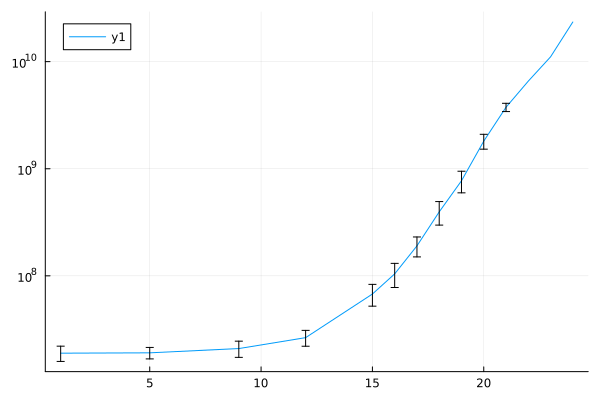

In [7]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10)

In [8]:
using LsqFit, Statistics

model(N, p) = p[1] .* (2 .^N) .+ p[2]

p0 = [1.0, 1e8]  # initial guess for [a, b]



fit = LsqFit.curve_fit(model, Ns, Ts, p0,inplace=false)

params = coef(fit)
errors = stderror(fit)

println("a = $(params[1]) ± $(errors[1])")
println("b = $(params[2]) ± $(errors[2])")



a = 1386.0732944702152 ± 20.757306693781707
b = 1.3143432156628042e8 ± 1.0747217827753736e8


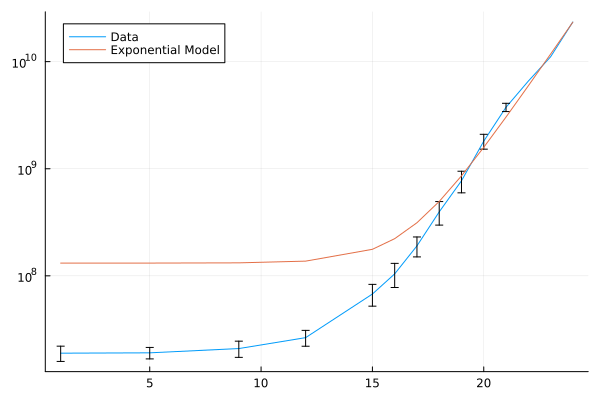

In [9]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10,label="Data")
Plots.plot!(Ns,model(Ns,params),yscale=:log10,label = "Exponential Model")

# Estimator Lookup Benchmarks

In [10]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]
means = []
meds = []

results = []

midPoint = mean(bvh.bbox,dims=2)[:,1]

for n in Ns

    bvh,tes,tets = standardEstimator(ps,n)


    bench = @benchmarkable DTFE(midPoint,bvh,tets,tes)
    stats = run(bench)
    push!(meds,median(stats).time)
    push!(means,mean(stats).time)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


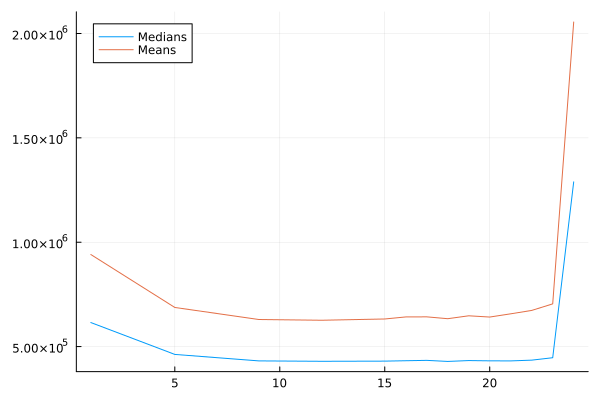

In [11]:
Plots.plot(Ns,meds,label="Medians")
Plots.plot!(Ns,means,label="Means")

# Leaf Hunting

In [12]:
function countLeaves(tree)
    count = 0
    
    if typeof(tree.leftChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.leftChild)
    end
    if typeof(tree.rightChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.rightChild)
    end

    return count

end

countLeaves(bvh.tree)

16687848

In [13]:
2^12

4096

In [19]:
Ns = [1,5,9,12,15,16,17,18,19,20]
leavz = []

for n in Ns

    bvh,tes,tets = standardEstimator(ps,n)

    push!(leavz,countLeaves(bvh.tree))
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20


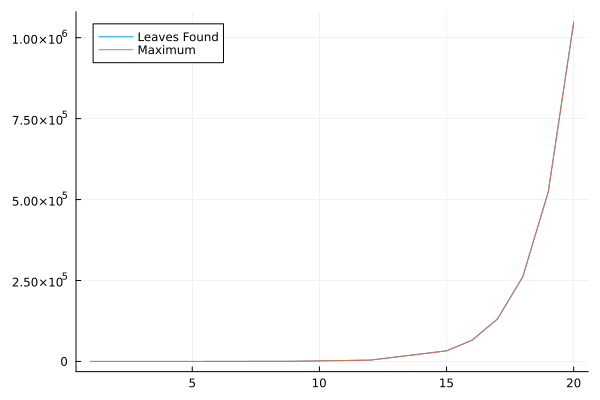

In [20]:
Plots.plot(Ns,leavz,label="Leaves Found")
Plots.plot!(Ns, 2 .^Ns,label="Maximum")

In [21]:
leavz - 2 .^Ns # fixed :)

10-element Vector{Int64}:
     0
     0
     0
     0
    -6
   -21
  -110
  -294
  -753
 -2297